## L = 3

Possible configurations: $ |\sigma\sigma\sigma\rangle, |\sigma\mu\sigma\rangle, |\mu\sigma\mu\rangle, |\mu\mu\mu\rangle $

In [1]:
import numpy as np
from numpy.linalg import eigh

In [2]:
def ising_fusCat_hamiltonian(r, theta):

    H = np.zeros(shape=(15, 15))

    # Elements
    H[0, 1:7] = -np.cos(theta)/np.sqrt(2)
    H[1:7, 0] = -np.cos(theta)/np.sqrt(2)
    for i in range(1, 13):
        H[i, i] = -2*r

    # The sin's
    H[7, 1] = H[7, 3] = -np.sin(theta)
    H[1, 7] = H[3, 7] = -np.sin(theta)

    H[8, 2] = H[8, 4] = -np.sin(theta)
    H[2, 8] = H[4, 8] = -np.sin(theta)

    H[9, 1] = H[9, 5] = -np.sin(theta)
    H[1, 9] = H[5, 9] = -np.sin(theta)

    H[10, 2] = H[10, 6] = -np.sin(theta)
    H[2, 10] = H[6, 10] = -np.sin(theta)

    H[11, 3] = H[11, 5] = -np.sin(theta)
    H[3, 11] = H[5, 11] = -np.sin(theta)

    H[12, 4] = H[12, 6] = -np.sin(theta)
    H[4, 12] = H[6, 12] = -np.sin(theta)

    # The cos's
    H[13, 7] = H[13, 9] = H[13, 11] = -np.cos(theta)
    H[7, 13] = H[9, 13] = H[11, 13] = -np.cos(theta)

    H[14, 8] = H[14, 10] = H[14, 12] = -np.cos(theta)
    H[8, 14] = H[10, 14] = H[12, 14] = -np.cos(theta)

    return H

In [27]:
H = ising_fusCat_hamiltonian(r=20.0, theta=np.pi/4)
energies, eigenvectors = eigh(H)

In [28]:
sorted_index = np.argsort(energies)
abs_tol = 0.0001

energy_deg_list = []
for index in sorted_index:
    if index == 0:
        energy_deg_list.append({"Energy": energies[0], "Degeneracy": 1})

    elif abs(energies[index] - energy_deg_list[-1]["Energy"]) < abs_tol:
        energy_deg_list[-1]["Degeneracy"] += 1

    else:
        energy_deg_list.append({"Energy": energies[index], "Degeneracy": 1})
        
energy_deg_list

[{'Energy': np.float64(-41.45040139046841), 'Degeneracy': 1},
 {'Energy': np.float64(-41.432431169608606), 'Degeneracy': 1},
 {'Energy': np.float64(-40.70710678118658), 'Degeneracy': 4},
 {'Energy': np.float64(-39.292893218813475), 'Degeneracy': 4},
 {'Energy': np.float64(-38.62462176937349), 'Degeneracy': 1},
 {'Energy': np.float64(-38.60508049791434), 'Degeneracy': 1},
 {'Energy': np.float64(0.03618782809531236), 'Degeneracy': 1},
 {'Energy': np.float64(0.03751166752291992), 'Degeneracy': 1},
 {'Energy': np.float64(0.03883533174658452), 'Degeneracy': 1}]

In [31]:
r = 20.0
theta = np.pi/4

E_plus = -(r + np.sin(theta)) + 0.5 * np.sqrt(4*(r + np.sin(theta))**2 + ((1 + 1/np.sqrt(2))*(np.cos(theta)))**2)
E_minus = -(r + np.sin(theta)) - 0.5 * np.sqrt(4*(r + np.sin(theta))**2 + ((1 + 1/np.sqrt(2))*(np.cos(theta)))**2)

print(E_plus, E_minus)

0.008794066779454823 -41.42300762915255


In [39]:
H_reduced = np.array([[0, -np.sqrt(3)*np.cos(theta)],
                     [-np.sqrt(3)*np.cos(theta), -2*(r+np.sin(theta))]])

ener, _ = eigh(H_reduced)
print(ener)

[-4.14504014e+01  3.61878281e-02]


In [37]:
r = 20.0
theta = np.pi/4
H_red = np.array([[0, np.cos(theta)],
                  [np.cos(theta), (1+np.sqrt(2))*r + 2*np.sqrt(2)*np.sin(theta)]])

ener, _ = eigh(H_red)
print(ener)

[-9.94150167e-03  5.02942127e+01]


## Code

In [11]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

# Constants for simple objects
I, PSI, SIGMA = 0, 1, 2

def is_valid_state(state):
    """Filter states based on the Z_2 grading constraint."""
    for i in range(len(state)):
        left, right = state[i], state[(i + 1) % len(state)]
        if (left == I and right == PSI) or (left == PSI and right == I):
            return False
    return True

def generate_representatives(L, m):
    """Generate orbit representatives and valid states for a specific momentum sector."""
    all_states = [np.array(list(np.base_repr(i, base=3).zfill(L)), dtype=int) for i in range(3**L)]
    valid_states = [s for s in all_states if is_valid_state(s)]
    
    visited = set()
    reps = []
    
    for state in valid_states:
        state_tuple = tuple(state)
        if state_tuple not in visited:
            orbit = [tuple(np.roll(state, shift)) for shift in range(L)]
            rep = min(orbit)
            periodicity = len(set(orbit))
            
            # Check for destructive interference in this k-sector
            if (m * periodicity) % L == 0:
                reps.append({'rep': rep, 'R': periodicity})
                
            visited.update(orbit)
            
    return reps

def find_representative_and_shift(state):
    """
    Returns the orbit representative and the number of left shifts 
    required to reach it from the original state.
    """
    L = len(state)
    orbit = [tuple(np.roll(state, shift)) for shift in range(L)]
    rep = min(orbit)
    shift_j = orbit.index(rep)
    return rep, shift_j

def solve_spectrum(L, r, theta, num_eigenvalues=5):
    """Solve lowest eigenvalues for all momentum sectors."""
    spectra = {}
    for m in range(L):
        k = 2 * np.pi * m / L
        reps = generate_representatives(L, m)
        
        if not reps:
            continue
            
        H_k = build_hamiltonian_block(L, k, reps, r, theta)
        
        if H_k.shape[0] > num_eigenvalues:
            evals, _ = eigsh(H_k, k=num_eigenvalues, which='SA')
        else:
            evals = np.linalg.eigvalsh(H_k.toarray())
            
        spectra[k] = evals
    return spectra

def is_mu(x):
    """Helper to identify if a site is in the vacuum sector {I, psi} -> {0, 1}"""
    return x in (0, 1)

def is_sigma(x):
    """Helper to identify if a site is an anyon {sigma} -> {2}"""
    return x == 2

def build_hamiltonian_block(L, k, reps, r, theta):
    """
    Constructs the Hamiltonian matrix for a specific momentum sector k.
    State representation: 0 = I, 1 = psi, 2 = sigma
    """
    dim = len(reps)
    H_k = lil_matrix((dim, dim), dtype=complex)
    rep_to_idx = {reps[idx]['rep']: idx for idx in range(dim)}
    
    # Outer loop: Iterate over all representative states in this k-sector
    for i, state_data in enumerate(reps):
        rep = state_data['rep']
        R_a = state_data['R']
        
        # Inner loop: Iterate over every lattice site j to apply local H_i
        for j in range(L):
            left = rep[(j - 1) % L]
            mid = rep[j]
            right = rep[(j + 1) % L]
            
            # ==========================================
            # 1. H_dw Evaluation (Equation 14)
            # ==========================================
            val_dw = 0.0
            
            if is_mu(left) and is_mu(mid) and is_sigma(right): val_dw = r
            elif is_sigma(left) and is_mu(mid) and is_mu(right): val_dw = r
            elif is_mu(left) and is_sigma(mid) and is_sigma(right): val_dw = r
            elif is_sigma(left) and is_sigma(mid) and is_mu(right): val_dw = r
            
            # Apply overall negative sign to the diagonal element
            H_k[i, i] -= val_dw 
            
            # ==========================================
            # 2. H_flip Evaluation (Equation 15)
            # ==========================================
            transitions = []
            
            # |mu, mu, mu> -> cos(theta) |mu, sigma, mu>
            if is_mu(left) and is_mu(mid) and is_mu(right):
                transitions.append((2, np.cos(theta)))
                
            # |mu, mu, sigma> -> sin(theta) |mu, sigma, sigma>
            elif is_mu(left) and is_mu(mid) and is_sigma(right):
                transitions.append((2, np.sin(theta)))
                
            # |mu, sigma, nu> -> delta_{mu,nu} cos(theta) |mu, mu, mu>
            elif is_mu(left) and is_sigma(mid) and is_mu(right):
                if left == right: # Enforces the Kronecker delta
                    transitions.append((left, np.cos(theta)))
                    
            # |sigma, mu, mu> -> sin(theta) |sigma, sigma, mu>
            elif is_sigma(left) and is_mu(mid) and is_mu(right):
                transitions.append((2, np.sin(theta)))
                
            # |mu, sigma, sigma> -> sin(theta) |mu, mu, sigma>
            elif is_mu(left) and is_sigma(mid) and is_sigma(right):
                transitions.append((left, np.sin(theta)))
                
            # |sigma, mu, sigma> -> [cos(theta)/sqrt(2)] |sigma, sigma, sigma>
            elif is_sigma(left) and is_mu(mid) and is_sigma(right):
                transitions.append((2, np.cos(theta) / np.sqrt(2)))
                
            # |sigma, sigma, mu> -> sin(theta) |sigma, mu, mu>
            elif is_sigma(left) and is_sigma(mid) and is_mu(right):
                transitions.append((right, np.sin(theta)))
                
            # |sigma, sigma, sigma> -> [cos(theta)/sqrt(2)] ( |sigma, 0, sigma> + |sigma, 1, sigma> )
            elif is_sigma(left) and is_sigma(mid) and is_sigma(right):
                amp = np.cos(theta) / np.sqrt(2)
                transitions.extend([(0, amp), (1, amp)])
                
            # Process all valid off-diagonal transitions
            for new_mid, amp in transitions:
                new_state = list(rep)
                new_state[j] = new_mid
                
                # Verify the Z_2 grading constraint isn't violated
                if is_valid_state(new_state):
                    new_rep, shift_j = find_representative_and_shift(new_state)
                    
                    if new_rep in rep_to_idx:
                        b_idx = rep_to_idx[new_rep]
                        R_b = reps[b_idx]['R']
                        
                        # Apply overall negative sign, transition amplitude, and momentum phase factor
                        matrix_element = -amp * np.sqrt(R_a / R_b) * np.exp(1j * k * shift_j)
                        H_k[b_idx, i] += matrix_element

    return H_k.tocsr()

In [12]:
solve_spectrum(L=6, r=20, theta=np.pi/4, num_eigenvalues=10)

{0.0: array([-82.82641449, -82.79138628, -82.10277402, -81.53956831,
        -81.45201996, -80.51205042, -80.06137129, -80.02498439,
        -80.01877125, -80.00366543]),
 1.0471975511965976: array([-82.30056427, -82.12318488, -81.82920057, -80.83628892,
        -80.65644533, -80.49650301, -80.03613505, -80.0210079 ,
        -80.00579332, -80.00008517]),
 2.0943951023931953: array([-82.10967672, -82.08128632, -81.87028085, -81.41216444,
        -81.31357046, -81.03005875, -80.85807618, -80.74479636,
        -80.36657522, -80.04373421]),
 3.141592653589793: array([-81.65564762, -81.43238297, -81.30656296, -81.13880655,
        -80.5411961 , -80.07015747, -80.07246533, -80.04996672,
        -80.00483751, -80.00252654]),
 4.1887902047863905: array([-82.10967672, -82.08128632, -81.87028085, -81.41216444,
        -81.31357046, -81.03005875, -80.85807618, -80.74479636,
        -80.36657522, -80.04373421]),
 5.235987755982989: array([-82.30056427, -82.12318488, -81.82920057, -80.83628892,
   

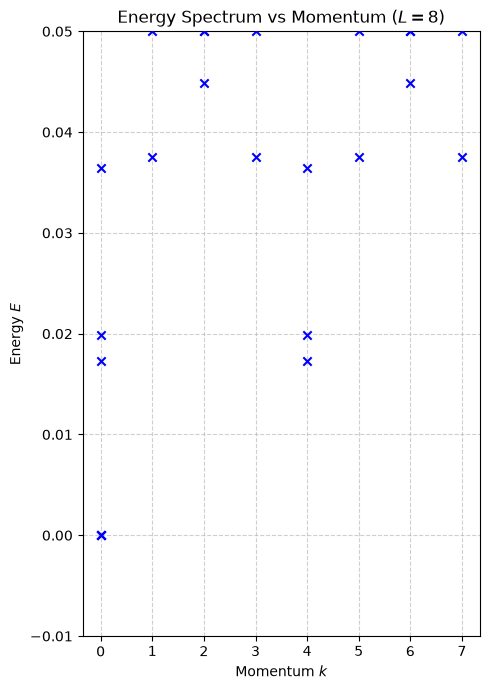

In [10]:
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import numpy as np

# Parameters
L = 8
r = -20
theta = np.pi / 4

# Momentum values
ms = np.arange(L)
E_list = []

# Diagonalize block-by-block
for m in ms:
    k = (2 * np.pi / L) * m
    reps = generate_representatives(L=L, m=m)
    H_block = build_hamiltonian_block(L=L, k=k, reps=reps, r=r, theta=theta)
    
    # energies, states = eigsh(H_block, k=10) # eigsh
    energies = np.linalg.eigvalsh(H_block.toarray())
    E_list.append(energies)

# Plot all energy levels against momentum k
plt.figure(figsize=(5, 7))

for idx, m in enumerate(ms):
    # Scatter plot all eigenvalues for each k sector
    plt.scatter([m] * len(E_list[idx]), E_list[idx] - min(E_list[0]), color='blue', zorder=3, marker='x') # reset reference level

# plt.ylim([-6, -2]) # r = 0, theta = pi/4
plt.ylim([-0.01, 0.05])
plt.xlabel(r'Momentum $k$')
plt.ylabel('Energy $E$')
plt.title(f'Energy Spectrum vs Momentum ($L={L}$)')
plt.xticks(ms, [f"${n}$" if n > 0 else "0" for n in range(L)])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [174]:
# np.roll (a: np.array, shift: integer, axis: None)
# If shift > 0, then shift to the right, if shift < 0, then to the left

example_array = [1, 2, 3, 4, 5]
np.roll(example_array, -1)

# np.base_repr (number: integer, base: integer, padding: 0)
# input a number and returns a string
# padding is the number of zeros you want to add to the left of the string

np.base_repr(number=2, base=2, padding=1)
np.base_repr(number=10, base=3, padding=0)

# .zfill (L: integer)
# a build-in python method for padding zeros until a length L is reached

np.base_repr(number=10, base=3, padding=0).zfill(10)

'0000000101'

In [175]:
# E.g. L = 3
# The possible values of k = 0, 2pi/3, 4pi/3

L = 3
reps_dict = {}

for k in [0, 2*np.pi/3, 4*np.pi/3]:
    rep = generate_representatives(L, k)
    reps_dict[f"k = {k:.2f}"] = rep

reps_dict

{'k = 0.00': [{'rep': (np.int64(0), np.int64(0), np.int64(0)), 'R': 1},
  {'rep': (np.int64(0), np.int64(0), np.int64(2)), 'R': 3},
  {'rep': (np.int64(0), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(1), np.int64(1)), 'R': 1},
  {'rep': (np.int64(1), np.int64(1), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(2), np.int64(2), np.int64(2)), 'R': 1}],
 'k = 2.09': [{'rep': (np.int64(0), np.int64(0), np.int64(2)), 'R': 3},
  {'rep': (np.int64(0), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(1), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(2), np.int64(2)), 'R': 3}],
 'k = 4.19': [{'rep': (np.int64(0), np.int64(0), np.int64(2)), 'R': 3},
  {'rep': (np.int64(0), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(1), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(2), np.int64(2)), 'R': 3}]}